# 03b — Manual behavioural inspection

This notebook reproduces the manual inspection in Section 3.4.2.

It examines the **10 highest-scoring U-named accounts in test window 0** using the raw successful-LogOn events. The K-means NHS is already frozen by notebook **02b** and is applied unchanged.

The review is descriptive. It does not assign verified human/machine ground-truth labels.

In [1]:
from pathlib import Path
import json
import pickle

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display

import nhs_split_eval as se
import nhs_feature_utils as fu

AUTH_PATH = "auth.txt.gz"
AUTH_PARQUET = Path("auth_main.parquet")
FEATURE_PATH = Path("static_features_v2/feat_final.parquet")
ACCOUNT_SPLIT_PATH = Path("account_split_static.json")
QUIET_HOURS_PATH = Path("quiet_hours.json")

SCORERS_PATH = Path("static_model_comparison/frozen_generic_scorers.pkl")
TEST_META_PATH = Path("static_test_evaluation/final_test_meta.json")

OUT = Path("manual_behavioural_inspection")
OUT.mkdir(exist_ok=True)

PANEL_DIR = OUT / "case_panels"
PANEL_DIR.mkdir(exist_ok=True)

CASE_KEY_PATH = OUT / "manual_top10_case_key.csv"
CASEBOOK_PATH = OUT / "manual_top10_casebook.pdf"
TABLE13_PATH = OUT / "Table_13_manual_behavioural_summary.csv"
DETAILED_PATH = OUT / "manual_top10_summary_with_accounts.csv"
FIGURE4_PATH = OUT / "Figure_04_manual_behavioural_inspection.png"
FIGURE4_PDF_PATH = OUT / "Figure_04_manual_behavioural_inspection.pdf"
META_PATH = OUT / "manual_inspection_meta.json"

PRIMARY_METHOD = "kmeans_core5"
PRIMARY_WINDOW = 0
WINDOW_DAYS = 14
WINDOW_S = WINDOW_DAYS * 86400
N_CASES = 10

print("Output directory:", OUT.resolve())

Output directory: ./manual_behavioural_inspection


## 1. Select the top 10 U-named test accounts

The ranking is generated with the frozen K-means scorer. No fitting occurs here.

In [2]:
required = [
    AUTH_PARQUET,
    FEATURE_PATH,
    ACCOUNT_SPLIT_PATH,
    QUIET_HOURS_PATH,
    SCORERS_PATH,
    TEST_META_PATH,
]
for path in required:
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path}")

split_obj = json.loads(ACCOUNT_SPLIT_PATH.read_text())
test_accounts = set(map(str, split_obj["test"]))

with open(SCORERS_PATH, "rb") as f:
    scorer_bundle = pickle.load(f)

primary_scorer = scorer_bundle["scorers"][PRIMARY_METHOD]

con = duckdb.connect()
feat = con.execute(
    f"SELECT * FROM '{FEATURE_PATH.as_posix()}'"
).df()
con.close()

feat["u"] = feat["u"].astype(str)
test_df = feat.loc[feat["u"].isin(test_accounts)].copy()

test_labeled = se.add_labels(test_df)
test_labeled["nhs"] = np.asarray(
    primary_scorer.score(test_labeled),
    dtype=float,
)

top10 = (
    test_labeled.loc[
        (test_labeled["win"] == PRIMARY_WINDOW)
        & (test_labeled["kind"] == "human")
    ]
    .sort_values(["nhs", "u"], ascending=[False, True])
    .head(N_CASES)
    .reset_index(drop=True)
)

top10["case_id"] = [f"M{i:02d}" for i in range(1, N_CASES + 1)]
top10["nhs_rank"] = np.arange(1, N_CASES + 1)

# The manual descriptions below come from the completed review.
# Check that the frozen ranking still selects the same accounts.
EXPECTED_TOP10 = [
    "U4559@DOM1",
    "U260@DOM1",
    "U4285@DOM1",
    "U9292@DOM1",
    "U4169@DOM1",
    "U1599@DOM1",
    "U2211@DOM1",
    "U6040@DOM1",
    "U6609@DOM1",
    "U679@DOM1",
]

if top10["u"].astype(str).tolist() != EXPECTED_TOP10:
    raise RuntimeError(
        "The frozen top-10 U-named test ranking no longer matches "
        "the completed manual review."
    )

case_key = top10[
    ["case_id", "nhs_rank", "u", "win", "nhs"]
].copy()

case_key.to_csv(CASE_KEY_PATH, index=False)
display(case_key)

,case_id,nhs_rank,u,win,nhs
0,M01,1,U4559@DOM1,0,2.570478
1,M02,2,U260@DOM1,0,2.531532
2,M03,3,U4285@DOM1,0,2.505680
3,M04,4,U9292@DOM1,0,2.501694
4,M05,5,U4169@DOM1,0,2.492455
5,M06,6,U1599@DOM1,0,2.465152
6,M07,7,U2211@DOM1,0,2.442211
7,M08,8,U6040@DOM1,0,2.439338
8,M09,9,U6609@DOM1,0,2.427295
9,M10,10,U679@DOM1,0,2.425944


## 2. Load raw successful-LogOn events

Only event time and destination computer are needed for the qualitative review.

In [3]:
QUIET_HOURS = [
    int(x) for x in json.loads(QUIET_HOURS_PATH.read_text())
]

con_raw, MAX_T, N_WIN = fu.initialise_duckdb(
    auth_parquet=AUTH_PARQUET,
    auth_path=AUTH_PATH,
    window_days=WINDOW_DAYS,
    force_auth_rebuild=False,
)

selected_users = case_key[["u", "case_id"]].copy()
con_raw.register("_selected_users", selected_users[["u"]])

raw = con_raw.execute(
    f"""
    SELECT
        CAST(e.u AS VARCHAR) AS u,
        CAST(e.t AS BIGINT) AS t,
        CAST(e.dst_comp AS VARCHAR) AS dst_comp
    FROM e
    INNER JOIN _selected_users AS s
      ON CAST(e.u AS VARCHAR) = s.u
    WHERE e.win = {PRIMARY_WINDOW}
    ORDER BY u, t
    """
).df()

con_raw.close()

raw = raw.merge(
    selected_users,
    on="u",
    how="left",
    validate="many_to_one",
)

print(f"Raw events: {len(raw):,}")
print("Accounts:", raw["u"].nunique())

Using existing auth_main.parquet
Success events: 1,038,590,151
Complete 14-day windows: 4
Discarded tail: 172799 seconds
DuckDB views restored: a, e


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw events: 101,472
Accounts: 10


## 3. Raw-event casebook

Each case is reviewed using four descriptive views:

1. day × relative-hour activity;
2. daily event volume;
3. inter-arrival-gap distribution;
4. destination concentration.

The casebook contains all 10 inspected accounts.

In [4]:
window_start = PRIMARY_WINDOW * WINDOW_S

def make_case_plot(case_id):
    g = raw.loc[
        raw["case_id"] == case_id
    ].sort_values("t").copy()

    t = g["t"].to_numpy(dtype=np.int64)
    days = ((t - window_start) // 86400).astype(int)
    hours = ((t % 86400) // 3600).astype(int)
    gaps = np.diff(t)

    heat = (
        pd.DataFrame({"day": days, "hour": hours})
        .groupby(["day", "hour"])
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=range(WINDOW_DAYS),
            columns=range(24),
            fill_value=0,
        )
    )

    daily = (
        pd.Series(days)
        .value_counts()
        .reindex(range(WINDOW_DAYS), fill_value=0)
        .sort_index()
    )

    dst = g["dst_comp"].value_counts(normalize=True).head(10)

    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.5))

    ax = axes[0, 0]
    im = ax.imshow(
        np.log1p(heat.values),
        aspect="auto",
        origin="lower",
    )
    for h in QUIET_HOURS:
        ax.axvline(h, linestyle="--", linewidth=0.6)
    ax.set_title("Day × relative-hour activity")
    ax.set_xlabel("Relative hour")
    ax.set_ylabel("Day")
    fig.colorbar(im, ax=ax, label="log(1 + count)")

    ax = axes[0, 1]
    ax.plot(daily.index, daily.values, marker="o")
    ax.set_title("Daily event volume")
    ax.set_xlabel("Day")
    ax.set_ylabel("Events")

    ax = axes[1, 0]
    if len(gaps):
        ax.hist(np.log10(gaps + 1), bins=40)
    ax.set_title("Inter-arrival gaps")
    ax.set_xlabel("log10(gap seconds + 1)")
    ax.set_ylabel("Count")

    ax = axes[1, 1]
    labels = [f"D{i+1}" for i in range(len(dst))]
    ax.barh(labels[::-1], dst.values[::-1])
    ax.set_title("Destination concentration")
    ax.set_xlabel("Share of events")

    fig.suptitle(f"{case_id} — raw-event review")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig


with PdfPages(CASEBOOK_PATH) as pdf:
    for case_id in case_key["case_id"]:
        fig = make_case_plot(case_id)
        fig.savefig(
            PANEL_DIR / f"{case_id}.png",
            dpi=180,
            bbox_inches="tight",
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("Saved:", CASEBOOK_PATH)

Saved: manual_behavioural_inspection/manual_top10_casebook.pdf


## 4. Recorded manual review — Supplementary Table 13

These descriptions are the **recorded observations from the completed manual review** used in the dissertation. They are not generated automatically from the plots.

In [5]:
OBSERVED_BEHAVIOUR = {
    "M01": (
        "Persistent high activity with repeated inter-arrival modes and "
        "recurring use of multiple destinations."
    ),
    "M02": (
        "High activity early in the window followed by a sharp decline, "
        "with repeated timing and one dominant destination."
    ),
    "M03": (
        "Episodic activity with a late surge, a strong repeated interval "
        "and highly concentrated destination use."
    ),
    "M04": (
        "Clear changes between low- and high-activity regimes, with one "
        "dominant repeated interval and one main destination."
    ),
    "M05": (
        "Mostly sustained activity with a short low-activity period, "
        "repeated timing and recurring use of two main destinations."
    ),
    "M06": (
        "Early high activity followed by lower activity, with a strong "
        "repeated interval and one dominant destination."
    ),
    "M07": (
        "A short high-volume period with repeated timing and concentrated "
        "destination use."
    ),
    "M08": (
        "Persistent activity across the window, repeated timing and a "
        "broader set of recurring destinations."
    ),
    "M09": (
        "Persistent activity with repeated timing but relatively diverse "
        "destination use."
    ),
    "M10": (
        "A shift into sustained higher activity, with a strong repeated "
        "interval and one dominant destination."
    ),
}

manual_summary = case_key.copy()
manual_summary["Observed raw behaviour"] = (
    manual_summary["case_id"].map(OBSERVED_BEHAVIOUR)
)

table13 = manual_summary[
    ["case_id", "nhs_rank", "Observed raw behaviour"]
].rename(columns={
    "case_id": "Case",
    "nhs_rank": "NHS rank",
})

table13.to_csv(TABLE13_PATH, index=False)
manual_summary.to_csv(DETAILED_PATH, index=False)

display(table13)

,Case,NHS rank,Observed raw behaviour
0,M01,1,Persistent high activity with repeated inter-a...
1,M02,2,High activity early in the window followed by ...
2,M03,3,"Episodic activity with a late surge, a strong ..."
3,M04,4,Clear changes between low- and high-activity r...
4,M05,5,Mostly sustained activity with a short low-act...
5,M06,6,Early high activity followed by lower activity...
6,M07,7,A short high-volume period with repeated timin...
7,M08,8,"Persistent activity across the window, repeate..."
8,M09,9,Persistent activity with repeated timing but r...
9,M10,10,"A shift into sustained higher activity, with a..."


## 5. Representative cases — dissertation Figure 4

The main dissertation figure shows M03, M04 and M05.

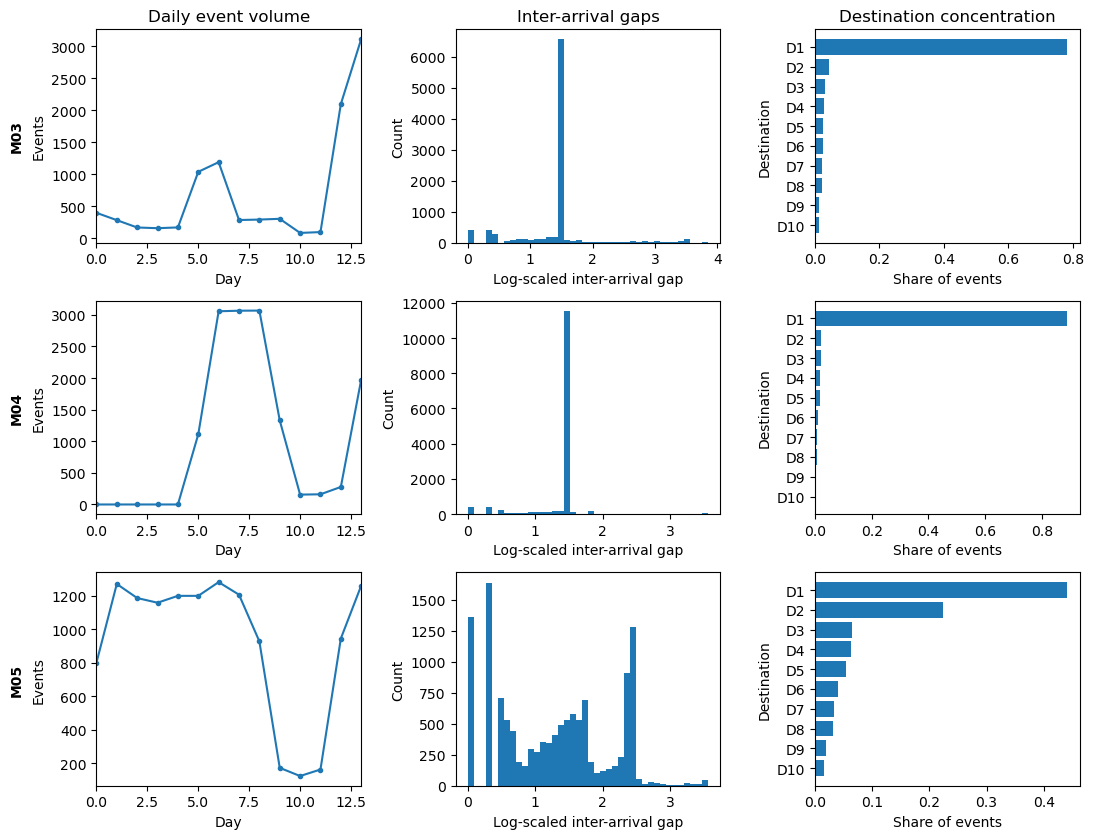

Saved: manual_behavioural_inspection/Figure_04_manual_behavioural_inspection.png


In [6]:
REP_CASES = ["M03", "M04", "M05"]

fig, axes = plt.subplots(
    nrows=len(REP_CASES),
    ncols=3,
    figsize=(11, 8.5),
)

for row, cid in enumerate(REP_CASES):
    g = raw.loc[
        raw["case_id"] == cid
    ].sort_values("t").copy()

    t = g["t"].to_numpy(dtype=np.int64)
    days = ((t - window_start) // 86400).astype(int)
    gaps = np.diff(t)

    daily = (
        pd.Series(days)
        .value_counts()
        .reindex(range(WINDOW_DAYS), fill_value=0)
        .sort_index()
    )

    axes[row, 0].plot(
        daily.index,
        daily.values,
        marker="o",
        markersize=3,
    )
    axes[row, 0].set_xlim(0, WINDOW_DAYS - 1)
    axes[row, 0].set_xlabel("Day")
    axes[row, 0].set_ylabel("Events")

    if len(gaps):
        axes[row, 1].hist(np.log10(gaps + 1), bins=40)
    axes[row, 1].set_xlabel("Log-scaled inter-arrival gap")
    axes[row, 1].set_ylabel("Count")

    dst = g["dst_comp"].value_counts(normalize=True).head(10)
    labels = [f"D{i+1}" for i in range(len(dst))]

    axes[row, 2].barh(labels[::-1], dst.values[::-1])
    axes[row, 2].set_xlabel("Share of events")
    axes[row, 2].set_ylabel("Destination")

    axes[row, 0].text(
        -0.30,
        0.5,
        cid,
        transform=axes[row, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontweight="bold",
    )

axes[0, 0].set_title("Daily event volume")
axes[0, 1].set_title("Inter-arrival gaps")
axes[0, 2].set_title("Destination concentration")

fig.tight_layout()

fig.savefig(
    FIGURE4_PATH,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE4_PDF_PATH,
    bbox_inches="tight",
)
plt.show()

print("Saved:", FIGURE4_PATH)

In [7]:
meta = {
    "pipeline_stage": "03b_manual_behavioural_inspection",
    "partition": "test",
    "window": PRIMARY_WINDOW,
    "selection": (
        "10 highest frozen K-means scores among U-named accounts"
    ),
    "models_refitted": False,
    "manual_review_role": (
        "descriptive raw-event inspection, not ground truth"
    ),
    "representative_cases": ["M03", "M04", "M05"],
    "outputs": {
        "case_key": str(CASE_KEY_PATH),
        "casebook": str(CASEBOOK_PATH),
        "table_13": str(TABLE13_PATH),
        "figure_4": str(FIGURE4_PATH),
    },
}

META_PATH.write_text(json.dumps(meta, indent=2))

print("Table 13:", TABLE13_PATH)
print("Figure 4:", FIGURE4_PATH)
print("Metadata:", META_PATH)

Table 13: manual_behavioural_inspection/Table_13_manual_behavioural_summary.csv
Figure 4: manual_behavioural_inspection/Figure_04_manual_behavioural_inspection.png
Metadata: manual_behavioural_inspection/manual_inspection_meta.json
